# Take-Home: Data Understanding — Fraud Detection
## CRISP-DM Phase 2
All required Python code is provided. **You are not assessed on writing code.** Run each cell and write your evidence-based answers in Markdown.
Do **not** clean, delete, impute, encode, transform or model the data. Continue from your Week 1 Business Understanding and explicitly use the feedback you received.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)
df=pd.read_csv("fraud_3.csv")
df.head()

,transaction_id,amount_eur,customer_avg_amount_30d,account_age_days,previous_transactions_24h,channel,country,hour,fraud_flag,post_investigation_loss_eur,days_to_departure,refund_after_trip_eur
0,T6000000,NaN,43.58,1357,4,ONLINE,FR,16,0,0.0,73,0.0
1,T6000001,17.82,43.80,1983,15,POS,FR,9,0,0.0,46,0.0
2,T6000002,143.45,31.24,612,12,Online,DE,9,0,0.0,5,0.0
3,T6000003,47.77,17.09,194,15,online,FR,9,0,0.0,167,0.0
4,T6000004,20.90,14.42,1622,5,Mobile,NL,13,0,0.0,199,0.0


## 1. Understand the dataset
Answer: What does one row represent? How many observations/variables are there? What is the identifier/business key? What is the main outcome? Which variables matter most to your business problem?

In [4]:
print("Shape:",df.shape)
df.info()
display(df.nunique(dropna=False).sort_values())

Shape: (2601, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2601 entries, 0 to 2600
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               2601 non-null   str    
 1   amount_eur                   2590 non-null   float64
 2   customer_avg_amount_30d      2601 non-null   float64
 3   account_age_days             2601 non-null   int64  
 4   previous_transactions_24h    2601 non-null   int64  
 5   channel                      2601 non-null   str    
 6   country                      2601 non-null   str    
 7   hour                         2601 non-null   int64  
 8   fraud_flag                   2601 non-null   int64  
 9   post_investigation_loss_eur  2601 non-null   float64
 10  days_to_departure            2601 non-null   int64  
 11  refund_after_trip_eur        2601 non-null   float64
dtypes: float64(4), int64(5), str(3)
memory usage: 244.0 KB


fraud_flag                        2
country                           4
channel                           5
hour                             24
previous_transactions_24h        24
post_investigation_loss_eur      59
refund_after_trip_eur           190
days_to_departure               210
account_age_days               1516
customer_avg_amount_30d        2133
amount_eur                     2349
transaction_id                 2600
dtype: int64

### Your answer
**One row represents:** one transaction 
**Dimensions:**   2600 entries/12 variables
**Identifier/business key:** transaction_id  
**Main outcome:** fraud_flag 
**Most relevant variables and why:** It is country and transaction in last 24H because it is not possible to make a transaction in the Netherlands and Spain within 2 hours of eachother. 

## 2. Data quality — observe, do not fix
Identify missing values, duplicates, unexpected types/categories and implausible ranges. Explain why any issue could matter.

In [5]:
quality=pd.DataFrame({"type":df.dtypes.astype(str),"missing":df.isna().sum(),"unique":df.nunique(dropna=False)})
display(quality)
print("Exact duplicates:",df.duplicated().sum())
for col in df.select_dtypes(exclude="number").columns:
 print("\n",col); print(df[col].value_counts(dropna=False).head(20))

,type,missing,unique
transaction_id,str,0,2600
amount_eur,float64,11,2349
customer_avg_amount_30d,float64,0,2133
account_age_days,int64,0,1516
previous_transactions_24h,int64,0,24
channel,str,0,5
country,str,0,4
hour,int64,0,24
fraud_flag,int64,0,2
post_investigation_loss_eur,float64,0,59


Exact duplicates: 1

 transaction_id
transaction_id
T6000055    2
T6000000    1
T6000001    1
T6000002    1
T6000003    1
T6000004    1
T6000005    1
T6000006    1
T6000007    1
T6000008    1
T6000009    1
T6000010    1
T6000011    1
T6000012    1
T6000013    1
T6000014    1
T6000015    1
T6000016    1
T6000017    1
T6000018    1
Name: count, dtype: int64

 channel
channel
Mobile    662
POS       654
online    644
Online    634
ONLINE      7
Name: count, dtype: int64

 country
country
NL    700
DE    650
BE    643
FR    608
Name: count, dtype: int64


### Data-quality findings
| Observation/issue | Variable(s) | Evidence | Why it matters |
|Missing|amount_eur|11|If there is fraud we do not know how much to reimburse the customer.|
|Duplicate|transaction_id |2| It changes the statistics of the dataset and we do now know if it is an error or not.|
|capital letter |channel |online/Online | There are different ways that it says online in the dataset, this could mean that the code doesnt read certain lines and that changes the output.|
| | | | |

## 3. Summary statistics
Interpret important values rather than copying output. Give at least three observations and explain their business meaning.

In [7]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,2601,2600,T6000055,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount_eur,2590.0,NaN,NaN,NaN,67.965232,69.830733,4.33,27.405,47.575,83.52,1094.12
customer_avg_amount_30d,2601.0,NaN,NaN,NaN,38.538381,23.33765,5.05,22.69,32.88,47.9,276.98
account_age_days,2601.0,NaN,NaN,NaN,1084.08689,648.483643,1.0,516.0,1076.0,1655.0,2200.0
previous_transactions_24h,2601.0,NaN,NaN,NaN,11.648597,6.86476,0.0,6.0,12.0,17.0,23.0
channel,2601,5,Mobile,662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2601,4,NL,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,2601.0,NaN,NaN,NaN,11.230296,6.850184,0.0,5.0,11.0,17.0,23.0
fraud_flag,2601.0,NaN,NaN,NaN,0.022299,0.147683,0.0,0.0,0.0,0.0,1.0
post_investigation_loss_eur,2601.0,NaN,NaN,NaN,1.835506,23.971907,0.0,0.0,0.0,0.0,1061.35


### Your interpretation
1. **Evidence:** ... **Business meaning:** ...  
2. **Evidence:** ... **Business meaning:** ...  
3. **Evidence:** ... **Business meaning:** ...

## 4. Understand the main outcome: `fraud_flag`
Explain its distribution in plain business language. Is it balanced, rare, concentrated, or continuous? Why might this matter later? What context is needed before calling the result good/bad?

fraud_flag
0    2543
1      58
Name: count, dtype: int64
fraud_flag
0    97.77
1     2.23
Name: proportion, dtype: float64


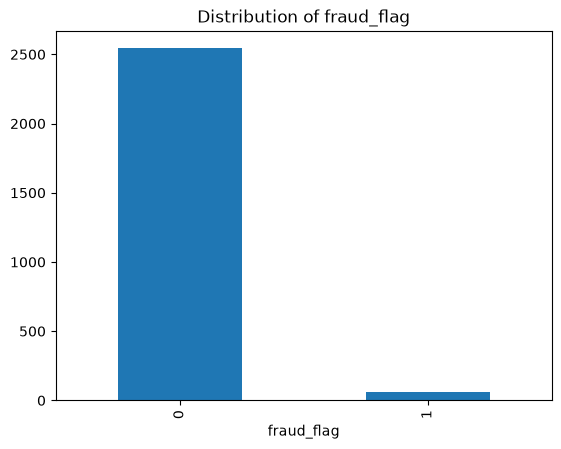

In [6]:
print(df["fraud_flag"].value_counts(dropna=False))
print((df["fraud_flag"].value_counts(normalize=True,dropna=False)*100).round(2))
df["fraud_flag"].value_counts(dropna=False).plot(kind="bar",title="Distribution of fraud_flag")
plt.show()

### Your outcome interpretation
...

## 5. Visual exploration
For every chart write: **Evidence → Business interpretation → Caution**. An association does not prove causation.

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

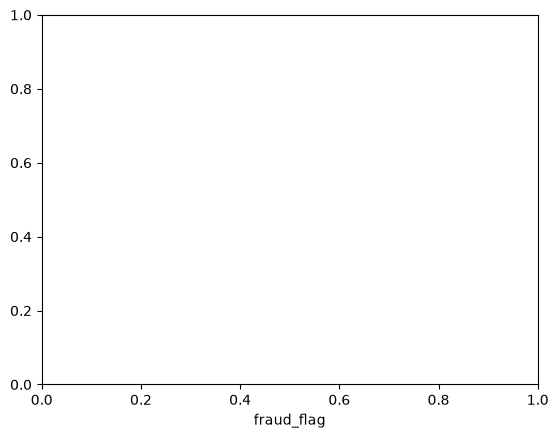

In [8]:
df.boxplot(column="transaction_id",by="fraud_flag"); plt.title("transaction_id by fraud_flag"); plt.suptitle(""); plt.show()

### Interpret `transaction_id`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

In [ ]:
df.boxplot(column="amount_eur",by="fraud_flag"); plt.title("amount_eur by fraud_flag"); plt.suptitle(""); plt.show()

### Interpret `amount_eur`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

In [ ]:
df.boxplot(column="hour_of_day",by="fraud_flag"); plt.title("hour_of_day by fraud_flag"); plt.suptitle(""); plt.show()

### Interpret `hour_of_day`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

In [ ]:
s=df.groupby("channel",dropna=False).agg(observations=("fraud_flag","size"),outcome=("fraud_flag","mean")).reset_index()
display(s)
s.plot(x="channel",y="outcome",kind="bar",legend=False); plt.title("Average fraud_flag by channel"); plt.show()

### Interpret `channel`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

In [ ]:
s=df.groupby("country",dropna=False).agg(observations=("fraud_flag","size"),outcome=("fraud_flag","mean")).reset_index()
display(s)
s.plot(x="country",y="outcome",kind="bar",legend=False); plt.title("Average fraud_flag by country"); plt.show()

### Interpret `country`
**Evidence:** ...  
**Business interpretation:** ...  
**Caution:** ...

## 6. Three key insights
Select your three most important findings. For each provide evidence and explain its relevance to the business problem.

1. ...
2. ...
3. ...

## 7. Revisit Week 1 Business Understanding
1. What feedback did you receive?
2. What did you change because of it?
3. Which assumptions are supported by this data?
4. Which are challenged or remain uncertain?
5. Should your business problem, objective, success criteria or stakeholder perspective be refined? Explain.

### Your reflection
...

## 8. Limitations and next questions
What can this dataset not tell you? What important information is missing? What additional data would help? What questions should carry forward?

### Your answer
...

# Submission check
- [ ] All supplied code cells run successfully.
- [ ] All Markdown prompts are answered in my own words.
- [ ] I interpret evidence rather than copy output.
- [ ] I link findings to my Business Understanding.
- [ ] I explicitly reflect on Week 1 feedback.
- [ ] I distinguish association from causation.
- [ ] I identify quality concerns but do not perform Data Preparation.
- [ ] I submit the `.ipynb`.

**Deadline: 23 September 2026 at 13:00 (CET).**